In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "dualtest_experiments" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "DUALTEST"))

print(PROJECT_ROOT)

/home/alumno1/Downloads/NLP_Proyecto_Final-main


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from experiment_utils import prepare_records
from target_model import HFLocalTarget
from reference_model import ReferenceModel
from scoring import score_texts

/home/alumno1/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
target = HFLocalTarget(
    model_name="EleutherAI/pythia-12B",
    device="cuda"
)

reference = ReferenceModel(
    model_name="EleutherAI/pythia-1.4B",
    device="cuda"
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

In [4]:
WIKIMIA_LENGTH = 256
PREFIX_LEN = WIKIMIA_LENGTH // 2
CONTINUATION_LEN = WIKIMIA_LENGTH // 2

wikimia_dir = PROJECT_ROOT / "dataset/raw/wikimia"
metadata_path = PROJECT_ROOT / "dataset/metadata/wikimia_metadata.csv"

print(wikimia_dir.exists())
print(metadata_path.exists())

True
True


In [5]:
meta = pd.read_csv(metadata_path)

meta_len = meta[
    meta["split"] == f"WikiMIA_length{WIKIMIA_LENGTH}"
].copy()

meta_len.shape, meta_len.head()

((82, 9),
                                file_name  \
 250  WikiMIA_WikiMIA_length256_00000.txt   
 251  WikiMIA_WikiMIA_length256_00001.txt   
 252  WikiMIA_WikiMIA_length256_00002.txt   
 253  WikiMIA_WikiMIA_length256_00003.txt   
 254  WikiMIA_WikiMIA_length256_00004.txt   
 
                                              file_path dataset_family  \
 250  dataset/raw/wikimia/WikiMIA_WikiMIA_length256_...        wikimia   
 251  dataset/raw/wikimia/WikiMIA_WikiMIA_length256_...        wikimia   
 252  dataset/raw/wikimia/WikiMIA_WikiMIA_length256_...        wikimia   
 253  dataset/raw/wikimia/WikiMIA_WikiMIA_length256_...        wikimia   
 254  dataset/raw/wikimia/WikiMIA_WikiMIA_length256_...        wikimia   
 
     source_dataset              split language  label estimated_membership  \
 250        WikiMIA  WikiMIA_length256  english      1               member   
 251        WikiMIA  WikiMIA_length256  english      1               member   
 252        WikiMIA  WikiMIA_length

In [6]:
records = []

for _, row in meta_len.iterrows():
    path = PROJECT_ROOT / row["file_path"]
    text = path.read_text(encoding="utf-8").strip()

    records.append({
        "id": row["file_name"],
        "text": text,
        "label": row["label"],
        "membership": row["estimated_membership"],
        "dataset": f"wikimia_length{WIKIMIA_LENGTH}",
    })

len(records), records[0]

(82,
 {'id': 'WikiMIA_WikiMIA_length256_00000.txt',
  'text': 'Hurricane Ana was the second tropical cyclone in 2014 to threaten the U.S. state of Hawaii with a direct hit, after Iselle in August. The twenty-first named storm and fifteenth hurricane of the 2014 Pacific hurricane season, Ana formed from a disturbance that formed in the Central Pacific in mid-October. It rapidly consolidated, and a tropical depression developed by October 13. Aided by favorable conditions, Ana gradually strengthened while moving westward, threatening to pass over the island chain of Hawaii once or several times as indicated by early forecasts. By October 17, it had strengthened to a hurricane south of Hawaii and reached its peak intensity shortly afterwards while also making its closest approach. Afterwards, Ana weakened and began to fluctuate in intensity as it turned to the north and eventually northeast as it rounded a subtropical ridge and interacted with a cold front before becoming a hurricane brie

In [7]:
texts = [r["text"] for r in records]
ids = [r["id"] for r in records]
labels = [r["label"] for r in records]
memberships = [r["membership"] for r in records]

len(texts), pd.Series(labels).value_counts()

(82,
 1    51
 0    31
 Name: count, dtype: int64)

In [8]:
df = score_texts(
    texts=texts,
    target=target,
    reference=reference,
    dataset_name=f"wikimia_length{WIKIMIA_LENGTH}",
    label=None,
    prefix_len=PREFIX_LEN,
    continuation_len=CONTINUATION_LEN,
    max_new_tokens=CONTINUATION_LEN,
)

df["id"] = ids
df["label"] = labels
df["membership"] = memberships
df["dataset"] = f"wikimia_length{WIKIMIA_LENGTH}"

df.head()

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


,id,label,run_length,p_rlb,edit_similarity,p_esb,prefix,ground_truth,target_completion,membership,dataset
0,WikiMIA_WikiMIA_length256_00000.txt,1,2,0.508290,0.308571,0.000000e+00,Hurricane Ana was the second tropical cyclone ...,peak intensity shortly afterwards while also ...,peak intensity of as a Category 1 hurricane....,member,wikimia_length256
1,WikiMIA_WikiMIA_length256_00001.txt,1,0,1.000000,0.208978,0.000000e+00,"The 2013–2016 epidemic of Ebola virus disease,...",following the commitment of substantial inter...,with the last case reported in March 2016. Th...,member,wikimia_length256
2,WikiMIA_WikiMIA_length256_00002.txt,1,0,1.000000,0.257576,1.109236e-31,The case of Ashya King concerns a boy named As...,it has funded treatment abroad since April 20...,the NHS did provide proton therapy in the Uni...,member,wikimia_length256
3,WikiMIA_WikiMIA_length256_00003.txt,0,0,1.000000,0.206430,1.026233e-28,The 16th Houston Film Critics Society Awards w...,"of the five Best Original Song nominees, whic...","by the Houston Symphony Orchestra, Houston Ba...",non_member,wikimia_length256
4,WikiMIA_WikiMIA_length256_00004.txt,1,2,0.437189,0.250000,4.110250e-35,The Cuban thaw (Spanish: Deshielo cubano) was ...,held in both Canada and Vatican City. The agr...,"held in Havana, Washington, D.C., and New Yor...",member,wikimia_length256


In [9]:
cols = [
    "id",
    "dataset",
    "label",
    "membership",
    "run_length",
    "p_rlb",
    "edit_similarity",
    "p_esb",
    "prefix",
    "ground_truth",
    "target_completion",
]

df = df[cols]
df.head()

,id,dataset,label,membership,run_length,p_rlb,edit_similarity,p_esb,prefix,ground_truth,target_completion
0,WikiMIA_WikiMIA_length256_00000.txt,wikimia_length256,1,member,2,0.508290,0.308571,0.000000e+00,Hurricane Ana was the second tropical cyclone ...,peak intensity shortly afterwards while also ...,peak intensity of as a Category 1 hurricane....
1,WikiMIA_WikiMIA_length256_00001.txt,wikimia_length256,1,member,0,1.000000,0.208978,0.000000e+00,"The 2013–2016 epidemic of Ebola virus disease,...",following the commitment of substantial inter...,with the last case reported in March 2016. Th...
2,WikiMIA_WikiMIA_length256_00002.txt,wikimia_length256,1,member,0,1.000000,0.257576,1.109236e-31,The case of Ashya King concerns a boy named As...,it has funded treatment abroad since April 20...,the NHS did provide proton therapy in the Uni...
3,WikiMIA_WikiMIA_length256_00003.txt,wikimia_length256,0,non_member,0,1.000000,0.206430,1.026233e-28,The 16th Houston Film Critics Society Awards w...,"of the five Best Original Song nominees, whic...","by the Houston Symphony Orchestra, Houston Ba..."
4,WikiMIA_WikiMIA_length256_00004.txt,wikimia_length256,1,member,2,0.437189,0.250000,4.110250e-35,The Cuban thaw (Spanish: Deshielo cubano) was ...,held in both Canada and Vatican City. The agr...,"held in Havana, Washington, D.C., and New Yor..."


In [ ]:
out_dir = PROJECT_ROOT / "results"
out_dir.mkdir(exist_ok=True)

out_path = out_dir / f"wikimia_length{WIKIMIA_LENGTH}_pythia12b_pythia14b.csv"
df.to_csv(out_path, index=False)

print(out_path)

/home/alumno1/Downloads/NLP_Proyecto_Final-main/results/wikimia_length256_pythia14b_pythia410m.csv


In [11]:
df.groupby("label")[[
    "run_length",
    "edit_similarity",
    "p_rlb",
    "p_esb"
]].mean()

,run_length,edit_similarity,p_rlb,p_esb
label,,,,
0,0.870968,0.255389,0.750725,2.438546e-07
1,1.078431,0.253236,0.729683,4.127246e-10


In [12]:
df.groupby("label")[[
    "run_length",
    "edit_similarity",
    "p_rlb",
    "p_esb"
]].median()

,run_length,edit_similarity,p_rlb,p_esb
label,,,,
0,0.0,0.254062,1.0,1.535401e-29
1,0.0,0.251634,1.0,2.802597e-43


In [13]:
df["log_p_esb"] = np.log10(
    np.maximum(df["p_esb"], 1e-300)
)

df.groupby("label")["log_p_esb"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,31.0,-113.155208,131.251276,-300.0,-300.0,-28.813778,-21.179107,-5.121507
1,51.0,-162.790073,136.058934,-300.0,-300.0,-42.552439,-32.689838,-7.737530


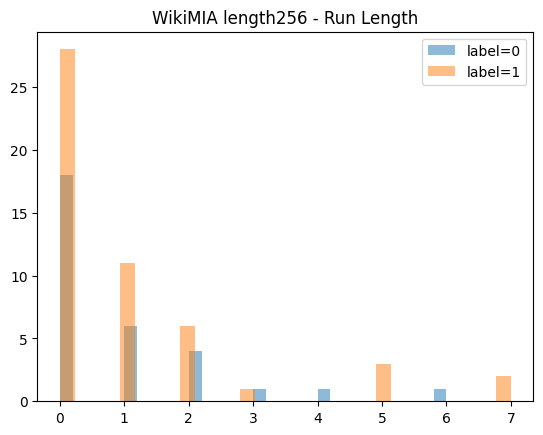

In [14]:
for label in [0, 1]:
    subset = df[df["label"] == label]
    plt.hist(subset["run_length"], bins=30, alpha=0.5, label=f"label={label}")

plt.legend()
plt.title(f"WikiMIA length{WIKIMIA_LENGTH} - Run Length")
plt.show()

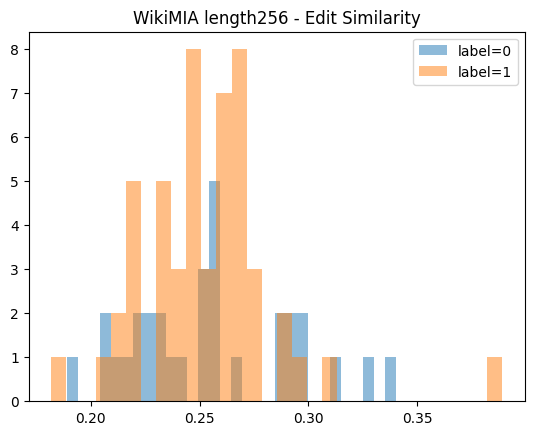

In [15]:
for label in [0, 1]:
    subset = df[df["label"] == label]
    plt.hist(subset["edit_similarity"], bins=30, alpha=0.5, label=f"label={label}")

plt.legend()
plt.title(f"WikiMIA length{WIKIMIA_LENGTH} - Edit Similarity")
plt.show()

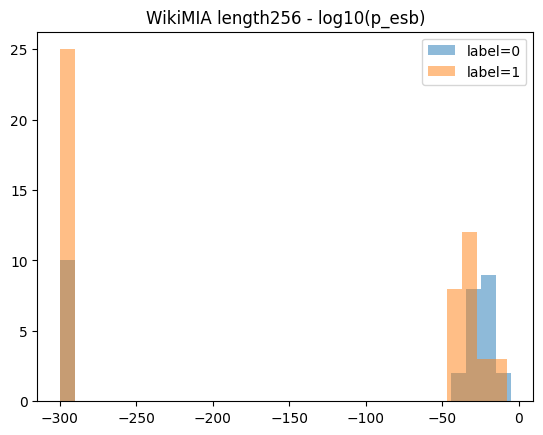

In [16]:
for label in [0, 1]:
    subset = df[df["label"] == label]
    plt.hist(subset["log_p_esb"], bins=30, alpha=0.5, label=f"label={label}")

plt.legend()
plt.title(f"WikiMIA length{WIKIMIA_LENGTH} - log10(p_esb)")
plt.show()

In [17]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    df["label"],
    df["edit_similarity"]
)


0.5079063883617962

In [18]:
roc_auc_score(
    df["label"],
    -np.log10(np.maximum(df["p_esb"], 1e-300))
)

0.6647691334598356

In [19]:
roc_auc_score(
    df["label"],
    df["run_length"]
)

0.5183428209993675